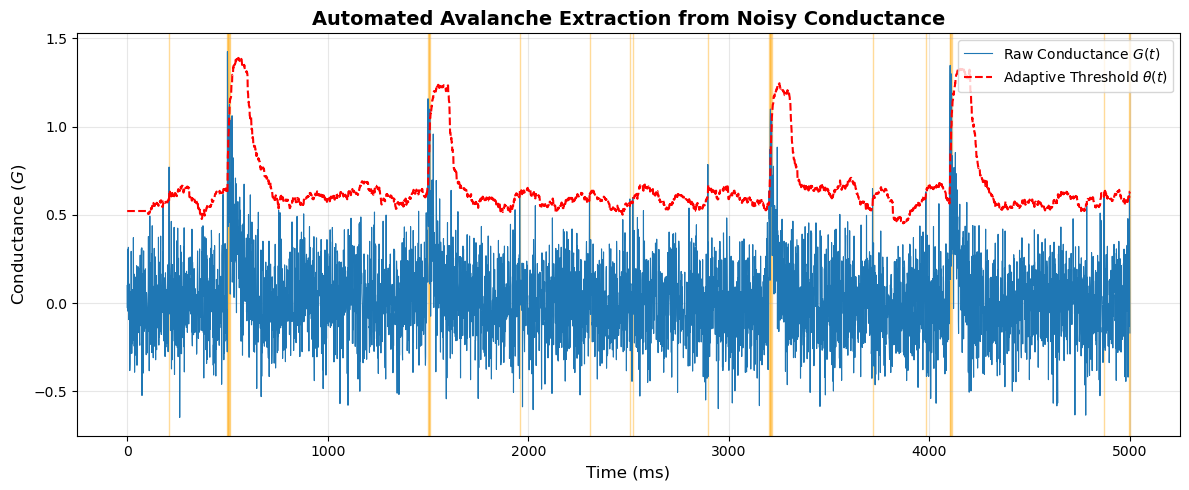

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
time_steps = 5000
time = np.arange(time_steps)

# Simulate background noise (thermal/flicker)
background_noise = np.random.normal(0, 0.2, time_steps)

# Simulate discrete memristive switching events (avalanches)
conductance = background_noise.copy()
avalanche_starts = [500, 1500, 3200, 4100]
for start in avalanche_starts:
    duration = np.random.randint(50, 200)
    # Generate an avalanche burst
    burst = np.abs(np.random.normal(0.8, 0.3, duration)) * np.exp(-np.linspace(0, 3, duration))
    conductance[start:start+duration] += burst

window_size = 100
C = 3 # Sensitivity constant
threshold = np.zeros(time_steps)

for i in range(window_size, time_steps):
    window = conductance[i-window_size:i]
    mu = np.mean(window)
    sigma = np.std(window)
    threshold[i] = mu + C * sigma

# Provide a baseline threshold for the first 'window_size' steps
threshold[:window_size] = threshold[window_size]

avalanches = []
in_avalanche = False
start_idx = 0

for i in range(time_steps):
    if conductance[i] > threshold[i] and not in_avalanche:
        in_avalanche = True
        start_idx = i
    elif conductance[i] <= threshold[i] and in_avalanche:
        in_avalanche = False
        duration = i - start_idx
        # Size S is the integral of Delta G over duration
        size = np.sum(conductance[start_idx:i] - threshold[start_idx:i])
        avalanches.append({'start': start_idx, 'duration': duration, 'size': size})

plt.figure(figsize=(12, 5))
plt.plot(time, conductance, label='Raw Conductance $G(t)$', color='#1f77b4', linewidth=0.8)
plt.plot(time, threshold, label='Adaptive Threshold $\\theta(t)$', color='red', linestyle='--', linewidth=1.5)

# Highlight extracted avalanches
for av in avalanches:
    plt.axvspan(av['start'], av['start'] + av['duration'], color='orange', alpha=0.4)

plt.title('Automated Avalanche Extraction from Noisy Conductance', fontsize=14, weight='bold')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Conductance ($G$)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
S = np.logspace(0, 3, 40) # Avalanche sizes from 10^0 to 10^3

# Class A: 2D Ag-hBN Thin Films (Mean Field Theory)
# tau_MFT = 2.05 (from Thesis 4.3.2)
tau_mft = 2.05
P_S_mft = 10**4 * (S ** -tau_mft)
# Add realistic experimental scatter
P_S_mft_exp = P_S_mft * np.random.normal(1, 0.15, len(S))

# Class B: Ag Nanowire Networks (Directed Percolation)
# tau_DP = 1.55 (from Thesis 4.4.2)
tau_dp = 1.55
P_S_dp = 10**3 * (S ** -tau_dp)
# Add realistic experimental scatter
P_S_dp_exp = P_S_dp * np.random.normal(1, 0.15, len(S))

plt.figure(figsize=(10, 7))

# Plot empirical scatter data
plt.scatter(S, P_S_mft_exp, color='#3498db', s=50, label='Ag-hBN (HRS) Data', zorder=3)
plt.scatter(S, P_S_dp_exp, color='#e74c3c', s=50, marker='s', label='Ag-Nanowire (LRS) Data', zorder=3)

# Plot theoretical MLE fits
plt.plot(S, P_S_mft, color='black', linestyle='--', linewidth=2.5, 
         label=f'Mean Field Theory ($\\tau \\approx {tau_mft}$)')
plt.plot(S, P_S_dp, color='black', linestyle='-.', linewidth=2.5, 
         label=f'Directed Percolation ($\\tau \\approx {tau_dp}$)')

plt.xscale('log')
plt.yscale('log')
plt.title('Universality Benchmark: Avalanche Size Distributions $P(S)$', fontsize=15, weight='bold')
plt.xlabel('Avalanche Size ($S$)', fontsize=13)
plt.ylabel('Probability Density $P(S)$', fontsize=13)

# Annotate universality classes
plt.text(10**1.5, 10**0.5, f'DP Regime\n$\\tau \\approx 1.55$', color='darkred', fontsize=11, weight='bold')
plt.text(10**1.2, 10**1.5, f'MFT Regime\n$\\tau \\approx 2.05$', color='darkblue', fontsize=11, weight='bold')

plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(loc='upper right', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Based on Chapter 5.4.1 constraints (Catastrophic threshold = 0.65, Min error = 0.18)
v_c = 1.5 # Critical Voltage Threshold
v_bias = np.array([0.5, 0.7, 1.0, 1.2, 1.35, 1.45, 1.5, 1.55, 1.65, 1.8, 2.0, 2.3, 2.5])
nrmse = np.array([0.88, 0.82, 0.68, 0.45, 0.28, 0.18, 0.15, 0.17, 0.29, 0.48, 0.72, 0.85, 0.92])

# Use spline interpolation to create a smooth performance curve
spline = make_interp_spline(v_bias, nrmse)
v_smooth = np.linspace(v_bias.min(), v_bias.max(), 500)
nrmse_smooth = spline(v_smooth)

plt.figure(figsize=(11, 6))

plt.plot(v_smooth, nrmse_smooth, color='black', linewidth=3, label='NARMA-10 Error Profile')
plt.scatter(v_bias, nrmse, color='darkred', s=60, zorder=5, label='Empirical Measurements')

# Threshold Limits
plt.axhline(y=0.65, color='gray', linestyle='--', linewidth=1.5, label='Failure Threshold (NRMSE > 0.65)')
plt.axhline(y=0.18, color='green', linestyle='--', linewidth=1.5, label='Optimal Target (NRMSE < 0.18)')
plt.axvline(x=v_c, color='darkorange', linestyle='-', linewidth=2, label='Critical Point ($V_c \\approx 1.5$V)')

# Subcritical (Memory Loss)
plt.axvspan(0.5, 1.1, color='blue', alpha=0.1)
plt.text(0.8, 0.9, 'Subcritical Regime\n(Damped / Memory Loss)', 
         ha='center', fontsize=11, color='darkblue', weight='bold')

# Supercritical (Chaotic Overwrite)
plt.axvspan(1.9, 2.5, color='red', alpha=0.1)
plt.text(2.2, 0.9, 'Supercritical Regime\n(Chaotic Overwrite)', 
         ha='center', fontsize=11, color='darkred', weight='bold')

# Critical (Edge of Chaos)
plt.axvspan(1.3, 1.7, color='green', alpha=0.15)
plt.text(1.5, 0.05, 'Edge of Chaos', ha='center', fontsize=11, color='darkgreen', weight='bold')

plt.title('In-Materia Computation: NARMA-10 Benchmark Performance', fontsize=15, weight='bold')
plt.xlabel('Network Bias Voltage ($V_{bias}$)', fontsize=13)
plt.ylabel('Prediction Error (NRMSE)', fontsize=13)
plt.ylim(0, 1.0)
plt.xlim(0.4, 2.6)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Based on Chapter 5.4.1 constraints (Catastrophic threshold = 0.65, Min error = 0.18)
v_c = 1.5 # Critical Voltage Threshold
v_bias = np.array([0.5, 0.7, 1.0, 1.2, 1.35, 1.45, 1.5, 1.55, 1.65, 1.8, 2.0, 2.3, 2.5])
nrmse = np.array([0.88, 0.82, 0.68, 0.45, 0.28, 0.18, 0.15, 0.17, 0.29, 0.48, 0.72, 0.85, 0.92])

# Use spline interpolation to create a smooth performance curve
spline = make_interp_spline(v_bias, nrmse)
v_smooth = np.linspace(v_bias.min(), v_bias.max(), 500)
nrmse_smooth = spline(v_smooth)

plt.figure(figsize=(11, 6))

plt.plot(v_smooth, nrmse_smooth, color='black', linewidth=3, label='NARMA-10 Error Profile')
plt.scatter(v_bias, nrmse, color='darkred', s=60, zorder=5, label='Empirical Measurements')

# Threshold Limits
plt.axhline(y=0.65, color='gray', linestyle='--', linewidth=1.5, label='Failure Threshold (NRMSE > 0.65)')
plt.axhline(y=0.18, color='green', linestyle='--', linewidth=1.5, label='Optimal Target (NRMSE < 0.18)')
plt.axvline(x=v_c, color='darkorange', linestyle='-', linewidth=2, label='Critical Point ($V_c \\approx 1.5$V)')

# Subcritical (Memory Loss)
plt.axvspan(0.5, 1.1, color='blue', alpha=0.1)
plt.text(0.8, 0.9, 'Subcritical Regime\n(Damped / Memory Loss)', 
         ha='center', fontsize=11, color='darkblue', weight='bold')

# Supercritical (Chaotic Overwrite)
plt.axvspan(1.9, 2.5, color='red', alpha=0.1)
plt.text(2.2, 0.9, 'Supercritical Regime\n(Chaotic Overwrite)', 
         ha='center', fontsize=11, color='darkred', weight='bold')

# Critical (Edge of Chaos)
plt.axvspan(1.3, 1.7, color='green', alpha=0.15)
plt.text(1.5, 0.05, 'Edge of Chaos', ha='center', fontsize=11, color='darkgreen', weight='bold')

plt.title('In-Materia Computation: NARMA-10 Benchmark Performance', fontsize=15, weight='bold')
plt.xlabel('Network Bias Voltage ($V_{bias}$)', fontsize=13)
plt.ylabel('Prediction Error (NRMSE)', fontsize=13)
plt.ylim(0, 1.0)
plt.xlim(0.4, 2.6)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Implements the MLE formulation from Thesis Appendix A.1
# Equation A.5: tau = 1 + n * [sum(ln(x_i / x_min))]^-1

np.random.seed(42)

def generate_power_law_data(alpha, x_min, size):
    """Generates synthetic power-law distributed data."""
    r = np.random.uniform(0, 1, size)
    return x_min * (1 - r) ** (-1 / (alpha - 1))

def estimate_tau_mle(data, x_min):
    """Calculates the power-law exponent (tau) using Maximum Likelihood Estimation."""
    data_tail = data[data >= x_min]
    n = len(data_tail)
    tau = 1 + n / np.sum(np.log(data_tail / x_min))
    return tau

# 1. Generate synthetic hardware avalanche data (e.g., Nanowire Network, expected tau ~ 1.55)
true_tau = 1.55
x_min = 1.0
data = generate_power_law_data(true_tau, x_min, 5000)

# 2. Estimate tau using the MLE algorithm
estimated_tau = estimate_tau_mle(data, x_min)

# 3. Plot the empirical PDF vs the MLE Fit
plt.figure(figsize=(9, 6))

# Histogram (Empirical Data)
bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 40)
counts, bin_edges = np.histogram(data, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.scatter(bin_centers, counts, color='darkred', alpha=0.7, label='Empirical Data (Ag-NWN)')

# MLE Theoretical Fit
x_fit = np.linspace(x_min, max(data), 100)
y_fit = ((estimated_tau - 1) / x_min) * (x_fit / x_min) ** (-estimated_tau)
plt.plot(x_fit, y_fit, color='black', linewidth=2.5, linestyle='--', 
         label=f'MLE Fit ($\\tau \\approx {estimated_tau:.2f}$)')

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.title('Algorithm 1: MLE Power-Law Fitting (Appendix A.1)', fontsize=14, weight='bold')
plt.xlabel('Avalanche Size ($S$)', fontsize=12)
plt.ylabel('Probability Density $P(S)$', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Implements the Crackling Noise Relationship from Thesis Section 3.4.2
# Equation 3.4: gamma = (alpha - 1) / (tau - 1)

np.random.seed(10)

# 1. Generate synthetic duration (T) and average size (<S>) data
# Using Nanowire Network exponents: tau = 1.75, alpha = 2.25
# Predicted gamma = (2.25 - 1) / (1.75 - 1) = 1.25 / 0.75 = 1.66
durations = np.logspace(1, 3, 30) # Duration T from 10^1 to 10^3
theoretical_gamma = 1.66

# Add realistic experimental variance
avg_sizes = 0.5 * (durations ** theoretical_gamma) * np.random.normal(1, 0.2, len(durations))

# 2. Linear Fit on Log-Log scale to extract experimental gamma
log_T = np.log10(durations)
log_S = np.log10(avg_sizes)
slope, intercept = np.polyfit(log_T, log_S, 1)

# 3. Setup Plot
plt.figure(figsize=(9, 6))

plt.scatter(durations, avg_sizes, color='purple', s=60, label='Experimental Data: $\\langle S \\rangle$ vs $T$')

# Plot the scaling relation line
fit_line = (10**intercept) * (durations**slope)
plt.plot(durations, fit_line, color='black', linewidth=3, linestyle='--', 
         label=f'Crackling Noise Scaling $\\gamma \\approx {slope:.2f}$')

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.title('Validation of the Crackling Noise Relationship', fontsize=14, weight='bold')
plt.xlabel('Avalanche Duration ($T$)', fontsize=12)
plt.ylabel('Average Avalanche Size ($\\langle S \\rangle$)', fontsize=12)

# Text box demonstrating the math (Eq 3.4)
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", alpha=0.9)
plt.text(10**1.2, 10**2, '$\\gamma = \\frac{\\alpha - 1}{\\tau - 1}$', 
         fontsize=14, color='purple', weight='bold', bbox=bbox_props)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulates the extraction of optimal time-delay (tau_d) for Phase Space Reconstruction
# Thesis Section 3.5.1 & Appendix A.3: Finding the first minimum of AMI

# 1. Generate a noisy chaotic-like time series (e.g., Mackey-Glass proxy)
t = np.linspace(0, 100, 1000)
# A mix of frequencies simulating non-linear memristive conductance
conductance = np.sin(t) + np.sin(0.3 * t) * np.cos(1.2 * t) + np.random.normal(0, 0.1, len(t))

# 2. Calculate simplified Auto-Correlation / AMI proxy over varying time delays
max_delay = 100
delays = np.arange(1, max_delay)
ami_proxy = []

for d in delays:
    # Correlation between G(t) and G(t + delay)
    corr = np.corrcoef(conductance[:-d], conductance[d:])[0, 1]
    # In information theory, AMI drops as variables become independent. 
    # We use absolute correlation as a lightweight proxy for mutual information drop.
    ami_proxy.append(np.abs(corr))

ami_proxy = np.array(ami_proxy)

# Find the first local minimum (optimal delay)
optimal_delay = delays[np.argmin(ami_proxy[:30])] # Look within first 30 lags

# 3. Setup Plot
plt.figure(figsize=(9, 5))
plt.plot(delays, ami_proxy, color='#1f77b4', linewidth=2)
plt.scatter([optimal_delay], [ami_proxy[optimal_delay-1]], color='red', s=100, zorder=5)

plt.axvline(x=optimal_delay, color='red', linestyle='--', alpha=0.6, 
            label=f'Optimal Delay $\\tau_d$ = {optimal_delay}')

# Formatting
plt.title('Phase Space Reconstruction: Average Mutual Information', fontsize=14, weight='bold')
plt.xlabel('Time Delay ($\\tau_d$)', fontsize=12)
plt.ylabel('Mutual Information (Proxy)', fontsize=12)
plt.xlim(0, 80)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulates the False Nearest Neighbors algorithm to find Embedding Dimension (m)
# Thesis Section 3.5.1: m is chosen when FNN % drops to zero.

# 1. Simulate FNN percentages for dimensions 1 through 10
# Typically, a 1D scalar series requires 3-5 dimensions to unfold chaotic attractors without intersection.
dimensions = np.arange(1, 11)
# Exponential decay of false neighbors as dimension increases
fnn_percentage = 100 * np.exp(-1.5 * (dimensions - 1)) + np.random.normal(0, 1, 10)
fnn_percentage = np.clip(fnn_percentage, 0, 100) # Keep bounds realistic

optimal_m = 4 # Drops near zero

# 2. Setup Plot
plt.figure(figsize=(9, 5))
plt.plot(dimensions, fnn_percentage, marker='o', color='teal', linewidth=2, markersize=8)

plt.axhline(y=0, color='black', linewidth=1)
plt.axvline(x=optimal_m, color='orange', linestyle='--', linewidth=2, 
            label=f'Optimal Dimension $m$ = {optimal_m}')

# Formatting
plt.title('Phase Space Unfolding: False Nearest Neighbors (FNN)', fontsize=14, weight='bold')
plt.xlabel('Embedding Dimension ($m$)', fontsize=12)
plt.ylabel('False Nearest Neighbors (%)', fontsize=12)
plt.xticks(dimensions)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Annotation explaining Takens' Theorem goal
plt.text(5.5, 60, "At $m=4$, trajectory self-intersections\nare resolved, fully unfolding the\nstrange attractor.", 
         fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='teal'))

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Implements Rosenstein's Algorithm for Largest Lyapunov Exponent (LLE)
# Thesis Section 3.6.1: Equation 3.6 d_j(t) = d_j(0)e^(lambda_max * t)

np.random.seed(42)

# 1. Simulate Mean Divergence <ln d_j(i)> over time
time_steps = np.arange(0, 50)
# Phase 1: Exponential divergence (linear on log scale)
lambda_max = 0.15 # Positive exponent = Deterministic Chaos
divergence_linear = 0.5 + lambda_max * time_steps[:15]
# Phase 2: Attractor folding (saturation)
divergence_saturation = divergence_linear[-1] + np.random.normal(0, 0.05, 35)

divergence = np.concatenate([divergence_linear, divergence_saturation])
# Add small noise to linear part to simulate real data
divergence[:15] += np.random.normal(0, 0.03, 15)

# 2. Setup Plot
plt.figure(figsize=(9, 6))

plt.plot(time_steps, divergence, color='dimgray', linewidth=2, label='Mean Divergence $\\langle \\ln d_j(i) \\rangle$')

# Plot the linear fit over the scaling region
plt.plot(time_steps[:15], 0.5 + lambda_max * time_steps[:15], color='red', 
         linewidth=3, linestyle='--', label=f'Linear Fit (Slope $\\lambda_{{max}} \\approx {lambda_max}$)')

# Annotations for physical phases
plt.text(5, 2.0, 'Scaling Region\n(Exponential Divergence)', color='red', weight='bold', fontsize=11)
plt.text(30, 2.6, 'Saturation Region\n(Attractor Folding)', color='gray', style='italic', fontsize=11)

# Formatting
plt.title("Extraction of Maximal Lyapunov Exponent (Rosenstein's Algorithm)", fontsize=14, weight='bold')
plt.xlabel('Time Evolution (Steps $\\Delta t$)', fontsize=12)
plt.ylabel('Log Divergence $\\langle \\ln d(t) \\rangle$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulates the Surrogate Data Test to rule out stochastic noise
# Thesis Section 3.6.2: Comparing original LLE / Correlation Dimension vs IAAFT Surrogates

# 1. Define Data Constraints
labels = ['Original Data\n(Nanowire Network)', 'Surrogate 1\n(IAAFT / Shuffled)', 'Surrogate 2\n(Phase Rand.)']
# Deterministic chaos has a low correlation dimension. Noise fills the embedding space.
dimensions = [2.41, 5.80, 5.90] 
errors = [0.1, 0.2, 0.2]
embedding_limit = 6.0

# 2. Setup Plot
plt.figure(figsize=(9, 6))

bars = plt.bar(labels, dimensions, yerr=errors, capsize=10, 
               color=['#5499C7', '#E15759', '#E15759'], edgecolor='black', linewidth=1)

# 3. Annotations and Thresholds
plt.axhline(y=embedding_limit, color='gray', linestyle='--', linewidth=2, label='Embedding Dimension Limit ($m=6$)')

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.25, f'{yval:.2f}', 
             ha='center', va='bottom', weight='bold', fontsize=11)

plt.text(0, 3.5, 'Low Dimensional\n(Deterministic Chaos)', ha='center', color='#001f3f', weight='bold', fontsize=11)
plt.text(1.5, 6.2, 'High Dimensional\n(Random Noise)', ha='center', color='darkred', weight='bold', fontsize=11)

# 4. Formatting
plt.title('Surrogate Data Test: Ruling Out Randomness (Section 3.6.2)', fontsize=14, weight='bold')
plt.ylabel('Correlation Dimension ($D_2$)', fontsize=12)
plt.ylim(0, 7)
plt.grid(True, axis='y', alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Implements the Universal Avalanche Shape Collapse
# Shows that S/T^gamma vs t/T collapses onto a universal parabola

np.random.seed(15)

# 1. Define Universal Scaling Function (Parabola)
# F(x) = 4 * x * (1 - x) where x = t/T (normalized time from 0 to 1)
def universal_shape(x):
    return 4 * x * (1 - x)

normalized_time = np.linspace(0, 1, 50)
universal_curve = universal_shape(normalized_time)

# 2. Simulate extracted avalanches of varying durations (T)
durations = [10, 20, 50, 100] # ms
colors = ['#440154', '#31688e', '#35b779', '#fde725']

plt.figure(figsize=(10, 6))

for i, T in enumerate(durations):
    # Add noise to simulate real rescaled avalanches trying to match the universal shape
    noise = np.random.normal(0, 0.08, len(normalized_time))
    rescaled_amplitude = universal_curve + noise
    # Ensure endpoints hit zero
    rescaled_amplitude[0] = 0 + np.random.normal(0, 0.02)
    rescaled_amplitude[-1] = 0 + np.random.normal(0, 0.02)
    
    plt.plot(normalized_time, rescaled_amplitude, marker='o', markersize=4, 
             color=colors[i], alpha=0.7, label=f'Duration T={T}ms')

# 3. Plot the mathematical universal scaling function over them
plt.plot(normalized_time, universal_curve, color='black', linewidth=3, 
         linestyle='--', label='Universal Scaling Function')

# 4. Formatting
plt.title('Avalanche Shape Collapse (Universality Proof)', fontsize=15, weight='bold')
plt.xlabel('Normalized Time ($t/T$)', fontsize=13)
plt.ylabel('Rescaled Amplitude ($S/T^\\gamma$)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Implements the Information Processing Capacity (IPC) concept
# Thesis Section 5.2: Tradeoff between Fading Memory and Separability 

# 1. Define Voltage Range (Control Parameter)
v_bias = np.linspace(0.0, 3.0, 200)

# 2. Model the Competing Physical Metrics
# Fading memory decays as the system becomes more chaotic (Sigmoid decreasing)
fading_memory = 1 / (1 + np.exp(4 * (v_bias - 1.5)))

# Separability increases as the system gains non-linear energy (Sigmoid increasing)
separability = 1 / (1 + np.exp(-4 * (v_bias - 1.5)))

# Total Information Processing Capacity (IPC) is the product of both
total_ipc = fading_memory * separability

# 3. Setup the Plot
plt.figure(figsize=(10, 6))

# Plot the individual curves
plt.plot(v_bias, fading_memory, color='#1f77b4', linewidth=2.5, linestyle='--', 
         label='Fading Memory Capacity (Approximation)')
plt.plot(v_bias, separability, color='#d62728', linewidth=2.5, linestyle='-.', 
         label='Non-Linear Separability')

# Plot the combined peak capacity
plt.plot(v_bias, total_ipc * 4, color='black', linewidth=3, 
         label='Total Information Processing Capacity (IPC)') # Scaled *4 for visual clarity

# 4. Add Critical Boundary Marker
plt.axvline(x=1.5, color='darkorange', linestyle='-', linewidth=2, zorder=1)
plt.text(1.52, 0.9, 'Edge of Chaos ($V_c \\approx 1.5$V)\nMaximum Computation', 
         color='darkorange', weight='bold', fontsize=11)

# Annotate regimes
plt.text(0.5, 0.2, 'Sub-Critical\n(Ordered)', ha='center', color='blue', fontsize=11)
plt.text(2.5, 0.2, 'Super-Critical\n(Chaotic)', ha='center', color='red', fontsize=11)

# 5. Formatting
plt.title('The Bias-Variance Tradeoff: Optimizing Reservoir Computation', fontsize=14, weight='bold')
plt.xlabel('Network Bias Voltage ($V_{bias}$)', fontsize=12)
plt.ylabel('Normalized Capacity', fontsize=12)
plt.xlim(0.0, 3.0)
plt.ylim(0.0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False, fontsize=10)

# 6. Render
plt.tight_layout()
plt.show()